In [1]:
import pandas as pd
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift
import multiprocessing

from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
import locale
import matplotlib as mpl

locale.setlocale(locale.LC_NUMERIC, "pt_BR.utf8")
plt.rcParams['axes.formatter.use_locale'] = True

# Configure text rendering to match your document's LaTeX engine
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex", 
    "font.family": "serif",      # Matches standard LaTeX Computer Modern Font
    "text.usetex": True,         # Forces LaTeX text processing
    "pgf.rcfonts": False,        # Ignores default Python fonts
})

reconciled_data = pd.read_pickle('reconciled_data.pkl')

kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

In [4]:
data_for_simulation = pd.read_pickle('data_for_simulation.pkl')

In [5]:
def solve_ODEs(data, model_name, param_dict):
    results_list = []
    unique_indices = data['index'].unique()
    for i in unique_indices:
        data_i = data.loc[data['index'] == i]
        print(f'Model: {model_name}')
        print(f'Index {i} of {unique_indices.max()}')
        clear_output(wait = True)
        F0 = data_i['F_H2_e_mol_s'].mean() + data_i['F_CO_e_mol_s'].mean()
    
        H2_CO = data_i['H2_CO'].mean()
        x_CO = 1 / ( 1 + H2_CO )
        x_H2 = 1 - x_CO
    
        # create reactor object
        T0 = (data_i['T_R_K'].mean(), 'K')
        x0 = {
                          'carbon monoxide': x_CO,
                          'hydrogen' : x_H2,
                      }
        reactor = PBR(T0 = T0, 
                      P0 = (data_i['P_abs_Pa'].mean(), 'Pa'), 
                      x0 = x0, 
                      F0 = (F0, 'mol/s'),
                      isothermal = True, 
                      ergun = False,
                      WT = (data_i['m_cat_g'].mean(), 'g'), 
                      W_steps = 20,
                      U = (300, 'W/m2/K'),
                      D = (7, 'mm'),
                      Dp = (0.1725, 'mm'),
                      pellet_density = (2530, 'kg/m3'),
                      Ta = T0,
                      liquid_phase = False,
                      units = 'SI',
                      solver_method = 'BDF',
                      rtol = 1e-4, atol = 1e-6,
                      calculate_equilibrium = False,
                      equilibrium_obj_fun_tolerance = 1e-12,
                      log = True,
                     )
    
        match model_name:
            case 'PowerLaw':
                from models_FTS.PowerLaw         import PowerLaw
                PowerLaw = PowerLaw()
                PowerLaw.kin_param_dict = param_dict
                reactor.add_model(PowerLaw)
            case 'Yates':
                from models_FTS.Yates            import Yates
                Yates = Yates()
                Yates.kin_param_dict = param_dict
                reactor.add_model(Yates)
            case 'Botes':
                from models_FTS.Botes            import Botes
                Botes = Botes()
                Botes.kin_param_dict = param_dict
                reactor.add_model(Botes)
            case 'Ojeda':
                from models_FTS.Ojeda            import Ojeda
                Ojeda = Ojeda()
                Ojeda.kin_param_dict = param_dict
                reactor.add_model(Ojeda)
            case 'Mousavi':
                from models_FTS.Mousavi_C1_C2_Emod          import Mousavi
                Mousavi = Mousavi()
                Mousavi.kin_param_dict = param_dict
                reactor.add_model(Mousavi)
            case 'Mousavi_no_correction':
                from models_FTS.Mousavi         import Mousavi
                Mousavi = Mousavi()
                Mousavi.kin_param_dict = param_dict
                reactor.add_model(Mousavi)
            case 'PowerLaw2':
                from models_FTS.PowerLaw2        import PowerLaw2
                PowerLaw2 = PowerLaw2()
                PowerLaw2.kin_param_dict = param_dict
                reactor.add_model(PowerLaw2)
        reactor.solve()
        # print(f'Params: {reactor.model.kin_param_dict}')

        sol_df = reactor.sol_dfs[model_name]
    
        F_H2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'hydrogen')].value.values[-1]
        F_CO_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon monoxide')].value.values[-1]
        F_H2O_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'water')].value.values[-1]
        F_CO2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon dioxide')].value.values[-1]

        for component in parafins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
        for component in olefins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
    
        data_i.loc[data_i.comp_name == 'hydrogen', f'Fout_{model_name}']  = F_H2_out_model
        data_i.loc[data_i.comp_name == 'carbon monoxide', f'Fout_{model_name}']  = F_CO_out_model
        data_i.loc[data_i.comp_name == 'water', f'Fout_{model_name}']  = F_H2O_out_model
        data_i.loc[data_i.comp_name == 'carbon dioxide', f'Fout_{model_name}']  = F_CO2_out_model

        results_list.append(data_i)
    data = pd.concat(results_list, ignore_index=True)
    return data

In [6]:
params_dict = {'PowerLaw': {'A_HCs': np.float64(4416.46906960849),
  'E_HCs': np.float64(39944.928292256314),
  'a': np.float64(-0.6828161505279903),
  'b': np.float64(0.20106198570261857),
  'A_WGS': np.float64(2066275395.2988818),
  'E_WGS': np.float64(164536.37699675243),
  'a_WGS': np.float64(0.016649380568140318),
  'b_WGS': np.float64(0.5269130869163346)},
 'Yates': {'k_ads': np.float64(1.6717109549448102e-05),
  'H_ads': np.float64(-516.2164489793478),
  'A_HCs': np.float64(6104717.734141292),
  'E_HCs': np.float64(200507.76236876496),
  'A_WGS': np.float64(2066275395.2988818),
  'E_WGS': np.float64(164536.37699675243),
  'a_WGS': np.float64(0.016649380568140318),
  'b_WGS': np.float64(0.5269130869163346)},
 'Botes': {'k_ads': np.float64(0.23640282022572684),
  'H_ads': np.float64(-0.004438512742530535),
  'A_HCs': np.float64(26426008000.666336),
  'E_HCs': np.float64(151833.62006988018),
  'A_WGS': np.float64(2066275395.2988818),
  'E_WGS': np.float64(164536.37699675243),
  'a_WGS': np.float64(0.016649380568140318),
  'b_WGS': np.float64(0.5269130869163346)},
 'Ojeda': {'k_ads': np.float64(3.561317145387408e-06),
  'H_ads': np.float64(3.724289200874538e-08),
  'A_HCs_1': np.float64(42.9568252221662),
  'E_HCs_1': np.float64(27145571.763164647),
  'A_HCs_2': np.float64(1.3671765453392632),
  'E_HCs_2': np.float64(80761.25633685807),
  'A_WGS': np.float64(2066275395.2988818),
  'E_WGS': np.float64(164536.37699675243),
  'a_WGS': np.float64(0.016649380568140318),
  'b_WGS': np.float64(0.5269130869163346)},
 'Mousavi': {'k_ads': np.float64(1.397972209918762e-05), # Pa**-1
  'H_ads': np.float64(932.9790718460237), # J/mol
  'A_HCs': np.float64(955.0608601894231), # mol/s/kg/Pa**1.75
  'E_HCs': np.float64(147203.9259840268), # J/mol
  'A_WGS': np.float64(2066275395.2988818), # mol/s/kg/Pa**(a+b)
  'E_WGS': np.float64(164536.37699675243), # J/mol
  'a_WGS': np.float64(0.016649380568140318), # dimensionless
  'b_WGS': np.float64(0.5269130869163346), # dimensionless
  'E_C1': 142602, # J/mol
  'E_C2': 153273}, # J/mol
 'Mousavi_no_correction': {'k_ads': np.float64(1.397972209918762e-05), # Pa**-1
  'H_ads': np.float64(932.9790718460237), # J/mol
  'A_HCs': np.float64(955.0608601894231), # mol/s/kg/Pa**1.75
  'E_HCs': np.float64(147203.9259840268), # J/mol
  'A_WGS': np.float64(2066275395.2988818), # mol/s/kg/Pa**(a+b)
  'E_WGS': np.float64(164536.37699675243), # J/mol
  'a_WGS': np.float64(0.016649380568140318), # dimensionless
  'b_WGS': np.float64(0.5269130869163346)}, # dimensionless
 'PowerLaw2': {'k_ads': np.float64(0.06297041078736515),
  'H_ads': np.float64(5.999191621283683e-05),
  'A_HCs': np.float64(1782.3029167737332),
  'E_HCs': np.float64(80522.86195996712),
  'a': np.float64(2.2904395836167582e-10),
  'b': np.float64(2.4046573727092717),
  'c': np.float64(1.2876788191352162),
  'A_WGS': np.float64(2066275395.2988818),
  'E_WGS': np.float64(164536.37699675243),
  'a_WGS': np.float64(0.016649380568140318),
  'b_WGS': np.float64(0.5269130869163346)}}

In [7]:
# select the models one wants to solve
model_names = [
    # 'PowerLaw', 
    # 'Yates', 
    # 'Botes', 
    # 'Ojeda', 
    'Mousavi',
    'Mousavi_no_correction',
    # 'PowerLaw2'
]

In [8]:
# solve for all models
for model in model_names:
    data_for_simulation = solve_ODEs(data_for_simulation, model, params_dict[model])

Model: Mousavi_no_correction
Index 305 of 305


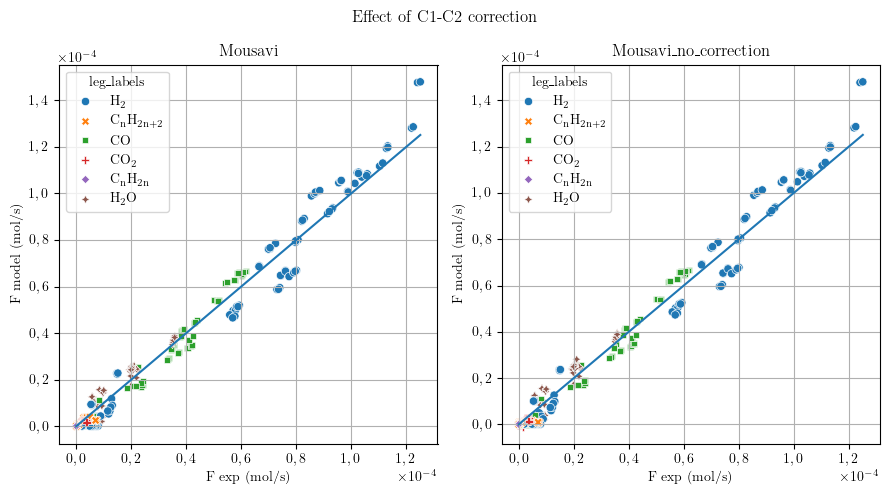

In [21]:
fig, axs = plt.subplots(1, 2, figsize = (9, 5))
flat_axs = axs.flatten()

for i, model in enumerate(model_names):
    max_xy = data_for_simulation['Fout_exp'].max()
    sns.scatterplot(data = data_for_simulation, 
                    x = 'Fout_exp', y = f'Fout_{model}', # F is in mol/s
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'F model (mol/s)')
    flat_axs[i].set_xlabel(r'F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')

fig.suptitle(f'Effect of C1-C2 correction')
plt.tight_layout()
fig_name = f'parity_effect_of_correction.pdf'
plt.savefig(fig_name, bbox_inches = 'tight')

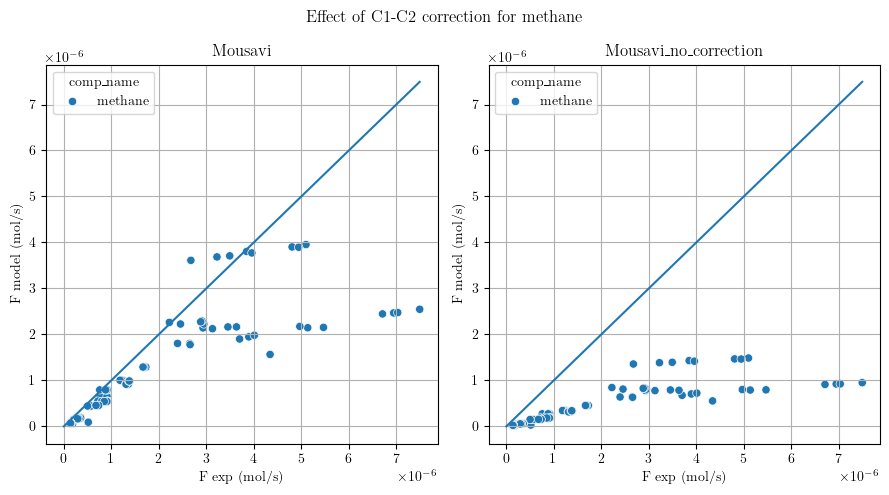

In [22]:
fig, axs = plt.subplots(1, 2, figsize = (9, 5))
flat_axs = axs.flatten()

component = 'methane'

for i, model in enumerate(model_names):
    max_xy = data_for_simulation.loc[data_for_simulation['comp_name'] == component, 'Fout_exp'].max()
    sns.scatterplot(data = data_for_simulation.loc[data_for_simulation['comp_name'] == component], 
                    x = 'Fout_exp', y = f'Fout_{model}', # F is in mol/s
                    ax=flat_axs[i],
                    hue = 'comp_name', style = 'comp_name',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'F model (mol/s)')
    flat_axs[i].set_xlabel(r'F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')

fig.suptitle(f'Effect of C1-C2 correction for {component}')
plt.tight_layout()
fig_name = f'parity_effect_of_correction_{component}.pdf'
plt.savefig(fig_name, bbox_inches = 'tight')

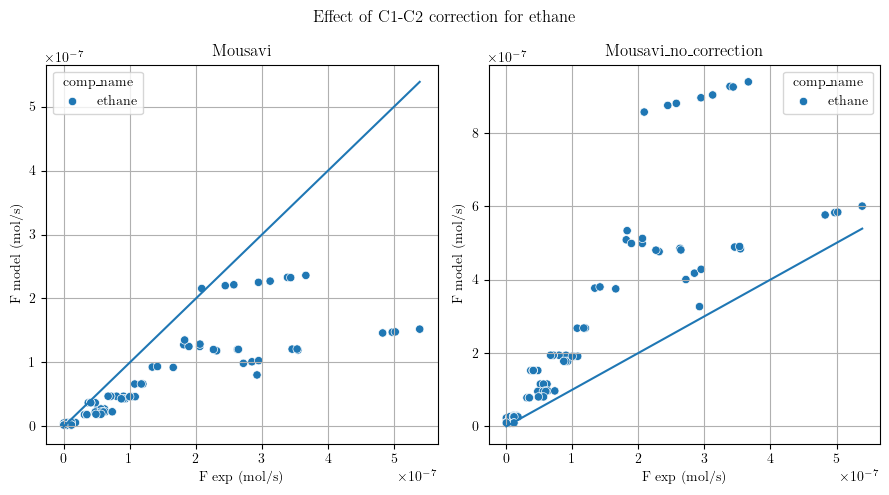

In [23]:
fig, axs = plt.subplots(1, 2, figsize = (9, 5))
flat_axs = axs.flatten()

component = 'ethane'

for i, model in enumerate(model_names):
    max_xy = data_for_simulation.loc[data_for_simulation['comp_name'] == component, 'Fout_exp'].max()
    sns.scatterplot(data = data_for_simulation.loc[data_for_simulation['comp_name'] == component], 
                    x = 'Fout_exp', y = f'Fout_{model}', # F is in mol/s
                    ax=flat_axs[i],
                    hue = 'comp_name', style = 'comp_name',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'F model (mol/s)')
    flat_axs[i].set_xlabel(r'F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')

fig.suptitle(f'Effect of C1-C2 correction for {component}')
plt.tight_layout()
fig_name = f'parity_effect_of_correction_{component}.pdf'
plt.savefig(fig_name, bbox_inches = 'tight')